In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage,
    fcluster
)

In [3]:
df = pd.read_csv("data/Mall_Customers.csv")

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (200, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0


In [9]:
features = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nShape:", X.shape)

X.head()

Selected Features:
['Annual Income (k$)', 'Spending Score (1-100)']

Shape: (200, 2)


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [13]:
linked_ward = linkage(
    X_scaled,
    method="ward"
)

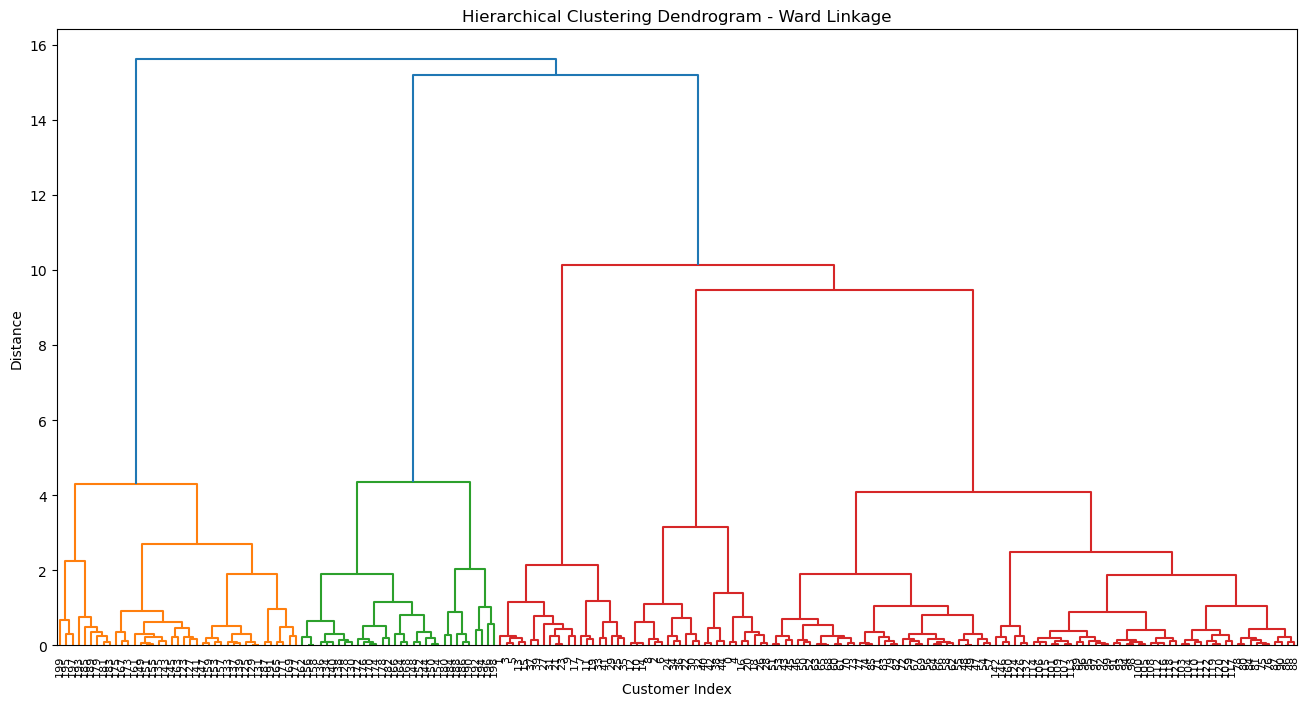

In [15]:
plt.figure(figsize=(16, 8))

dendrogram(
    linked_ward,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Customer Index")
plt.ylabel("Distance")

plt.show()

In [17]:
linkage_methods = [
    "ward",
    "complete",
    "average",
    "single"
]

linkage_results = {}

for method in linkage_methods:
    linkage_results[method] = linkage(
        X_scaled,
        method=method
    )

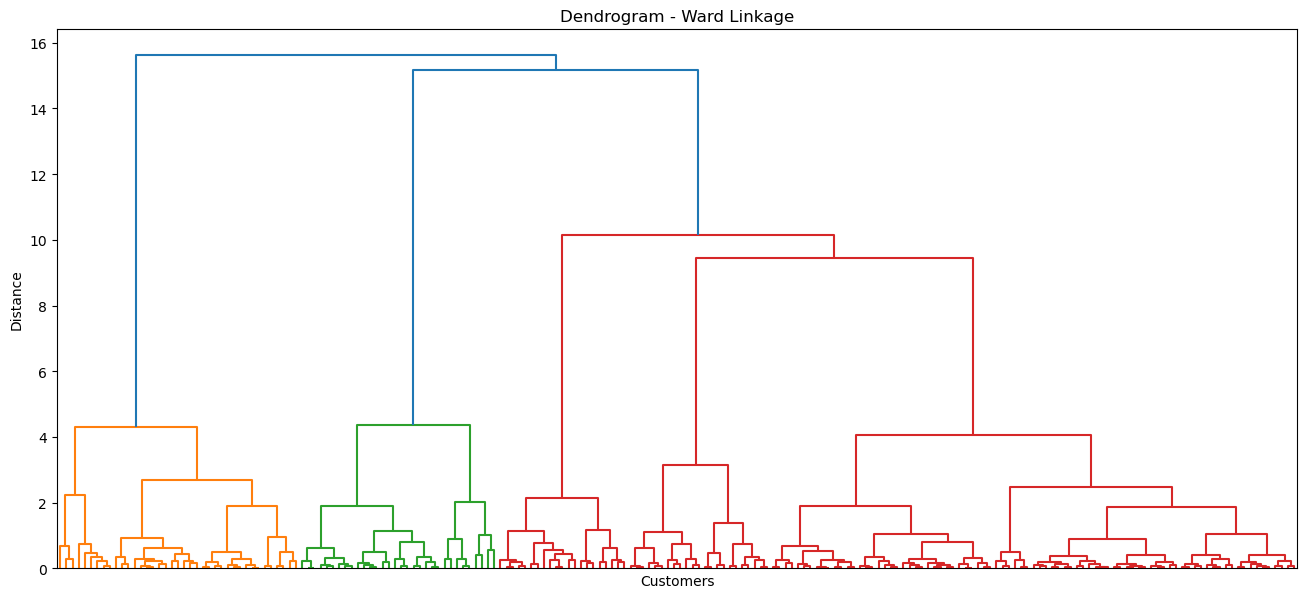

In [19]:
plt.figure(figsize=(16, 7))

dendrogram(
    linkage_results["ward"],
    no_labels=True
)

plt.title("Dendrogram - Ward Linkage")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

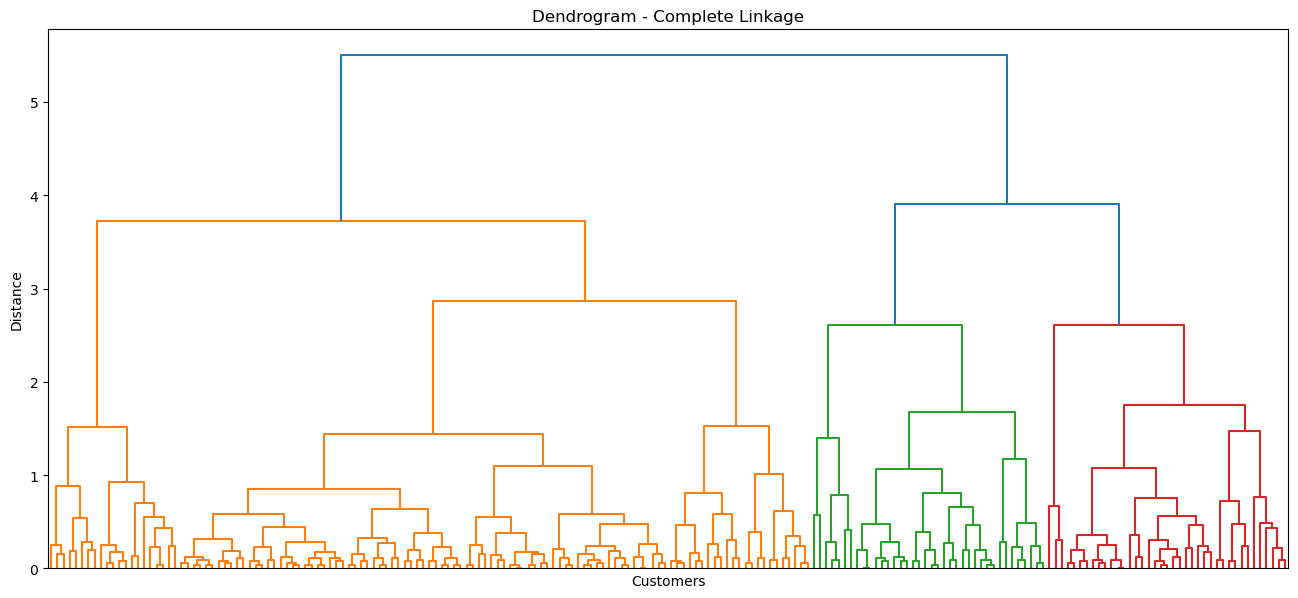

In [21]:
plt.figure(figsize=(16, 7))

dendrogram(
    linkage_results["complete"],
    no_labels=True
)

plt.title("Dendrogram - Complete Linkage")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

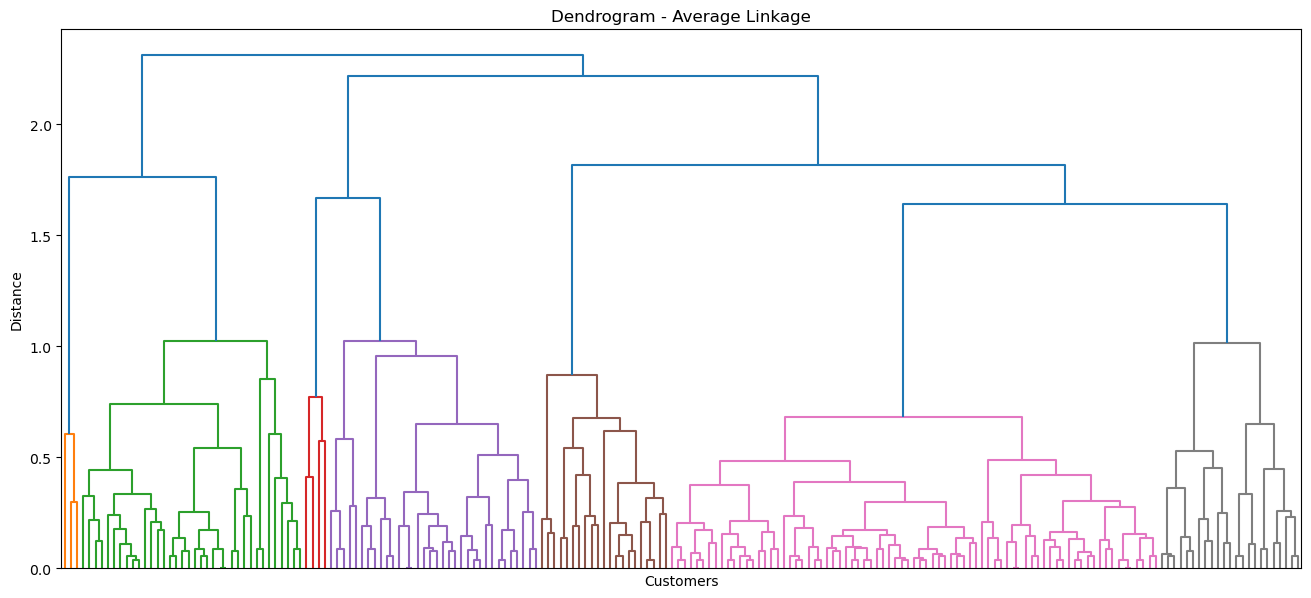

In [23]:
plt.figure(figsize=(16, 7))

dendrogram(
    linkage_results["average"],
    no_labels=True
)

plt.title("Dendrogram - Average Linkage")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

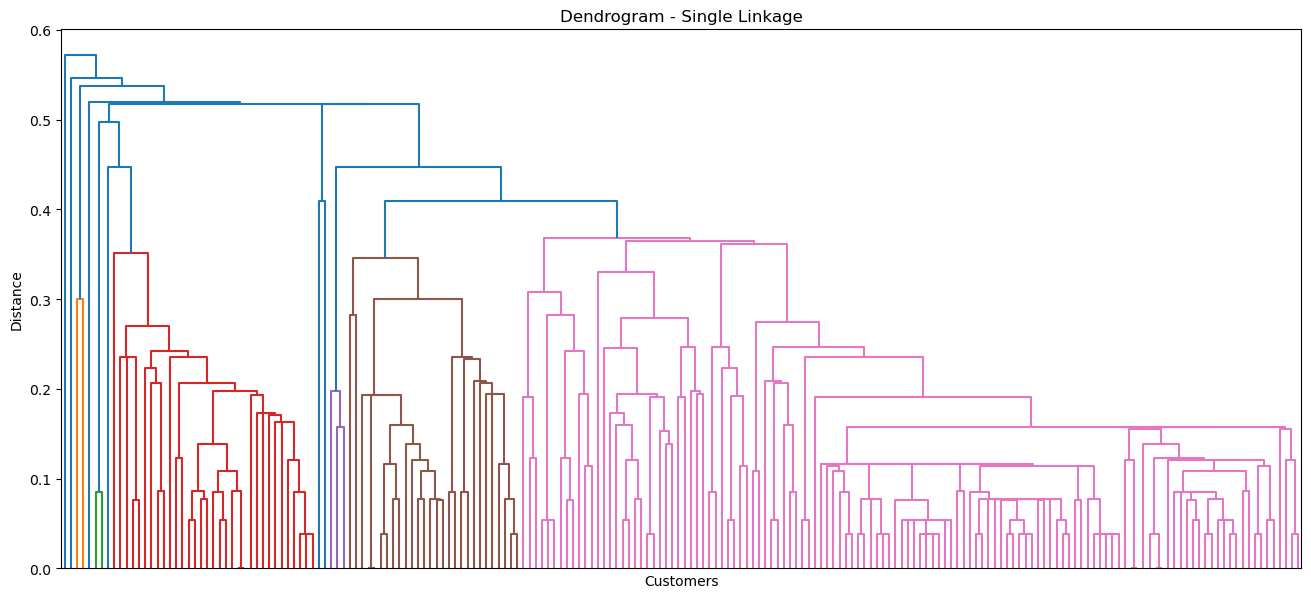

In [25]:
plt.figure(figsize=(16, 7))

dendrogram(
    linkage_results["single"],
    no_labels=True
)

plt.title("Dendrogram - Single Linkage")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [27]:
silhouette_scores_hierarchical = []

k_values = range(2, 11)

for k in k_values:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores_hierarchical.append(score)

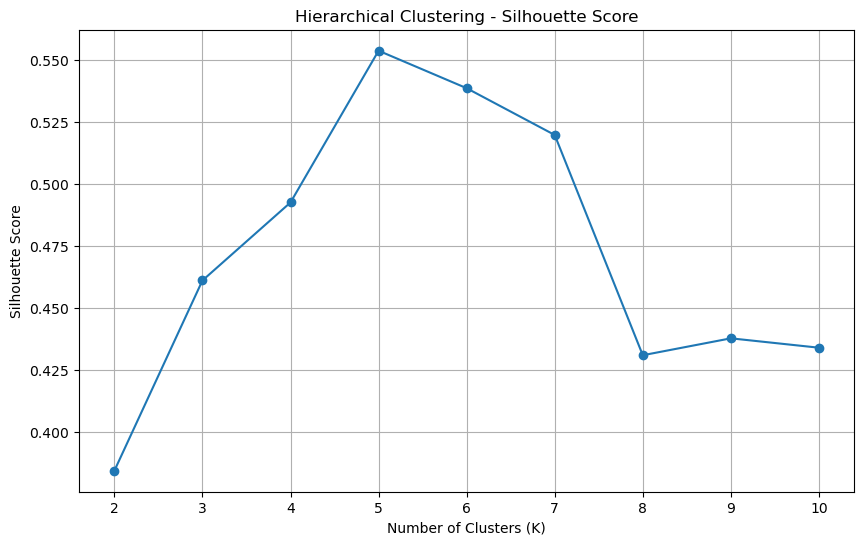

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores_hierarchical,
    marker="o"
)

plt.title("Hierarchical Clustering - Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [31]:
best_index = np.argmax(
    silhouette_scores_hierarchical
)

best_k_hierarchical = list(k_values)[best_index]

best_score_hierarchical = (
    silhouette_scores_hierarchical[best_index]
)

print(
    "Best K:",
    best_k_hierarchical
)

print(
    "Best Silhouette Score:",
    round(best_score_hierarchical, 4)
)

Best K: 5
Best Silhouette Score: 0.5538


In [33]:
print("K-Means Silhouette Score: 0.5547")
print(
    "Hierarchical Silhouette Score:",
    round(best_score_hierarchical, 4)
)

K-Means Silhouette Score: 0.5547
Hierarchical Silhouette Score: 0.5538


In [35]:
final_hierarchical = AgglomerativeClustering(
    n_clusters=best_k_hierarchical,
    linkage="ward"
)

hierarchical_labels = final_hierarchical.fit_predict(
    X_scaled
)

In [37]:
np.unique(hierarchical_labels)

array([0, 1, 2, 3, 4])

In [39]:
df["Hierarchical_Cluster"] = hierarchical_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Hierarchical_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


In [41]:
hierarchical_counts = (
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

print(hierarchical_counts)

Hierarchical_Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64


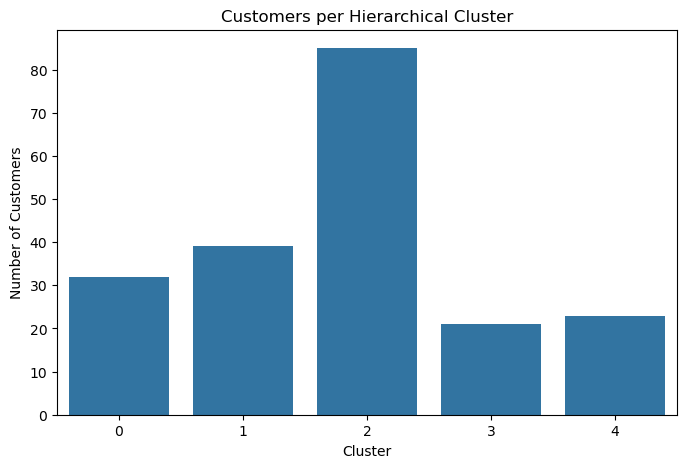

In [43]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Hierarchical_Cluster"
)

plt.title("Customers per Hierarchical Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

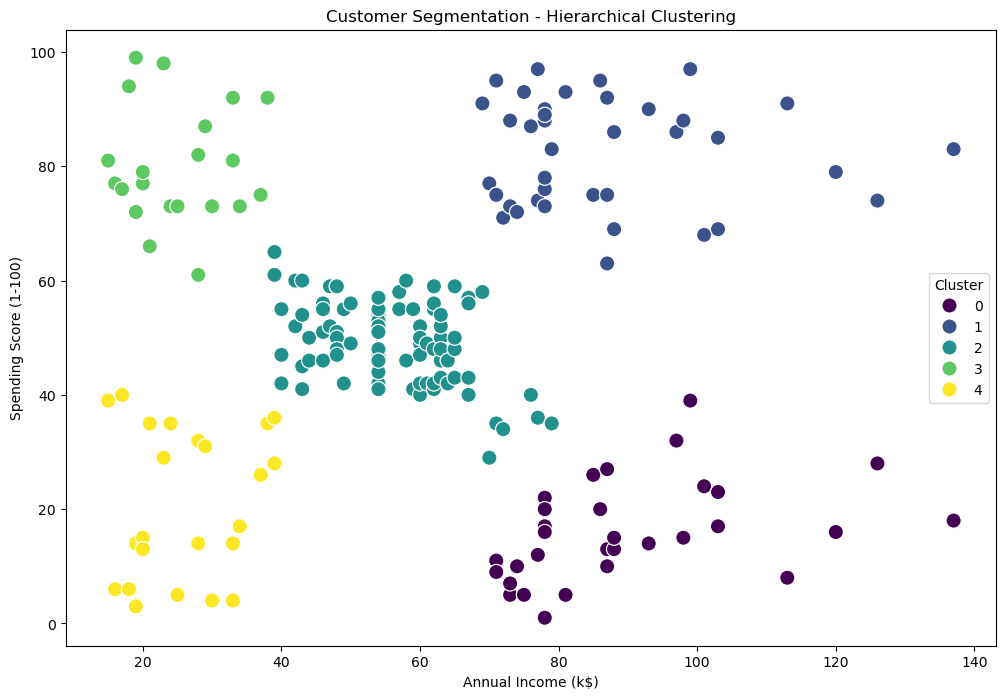

In [45]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Hierarchical_Cluster",
    palette="viridis",
    s=120
)

plt.title(
    "Customer Segmentation - Hierarchical Clustering"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend(
    title="Cluster"
)

plt.show()

In [47]:
hierarchical_profile = df.groupby(
    "Hierarchical_Cluster"
).agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
).round(2)

hierarchical_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending
Hierarchical_Cluster,,,,
0,32,41.00,89.41,15.59
1,39,32.69,86.54,82.13
2,85,42.48,55.81,49.13
3,21,25.33,25.10,80.05
4,23,45.22,26.30,20.91


In [49]:
hierarchical_profile.sort_values(
    "Average_Spending",
    ascending=False
)

,Customer_Count,Average_Age,Average_Income,Average_Spending
Hierarchical_Cluster,,,,
1,39,32.69,86.54,82.13
3,21,25.33,25.10,80.05
2,85,42.48,55.81,49.13
4,23,45.22,26.30,20.91
0,32,41.00,89.41,15.59


In [51]:
final_hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Final Hierarchical Silhouette Score:",
    round(final_hierarchical_score, 4)
)

Final Hierarchical Silhouette Score: 0.5538


In [53]:
linkage_scores = {}

for method in ["ward", "complete", "average", "single"]:
    
    model = AgglomerativeClustering(
        n_clusters=5,
        linkage=method
    )
    
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    linkage_scores[method] = score

linkage_scores

{'ward': 0.5538089226688662,
 'complete': 0.5531118656926702,
 'average': 0.4794263081846086,
 'single': 0.2758004412314313}

In [55]:
linkage_comparison = pd.DataFrame(
    list(linkage_scores.items()),
    columns=["Linkage", "Silhouette_Score"]
)

linkage_comparison.sort_values(
    "Silhouette_Score",
    ascending=False
)

,Linkage,Silhouette_Score
0,ward,0.553809
1,complete,0.553112
2,average,0.479426
3,single,0.275800


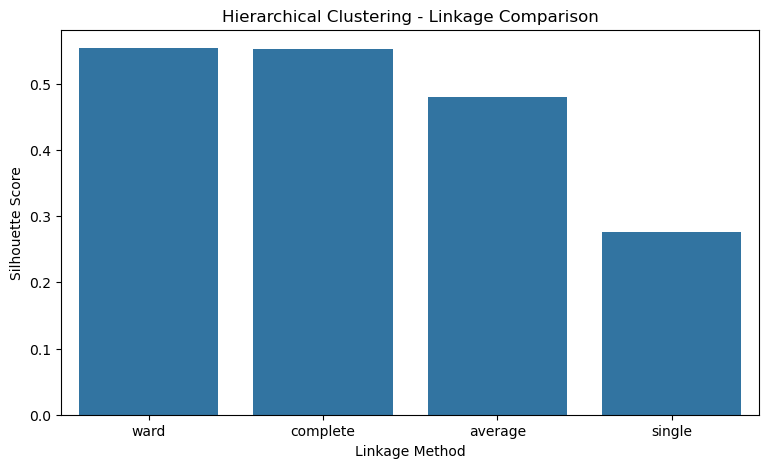

In [57]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=linkage_comparison,
    x="Linkage",
    y="Silhouette_Score"
)

plt.title("Hierarchical Clustering - Linkage Comparison")
plt.xlabel("Linkage Method")
plt.ylabel("Silhouette Score")

plt.show()

In [59]:
algorithm_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical"
    ],
    "Silhouette_Score": [
        0.5547,
        final_hierarchical_score
    ]
})

algorithm_comparison

,Algorithm,Silhouette_Score
0,K-Means,0.554700
1,Hierarchical,0.553809


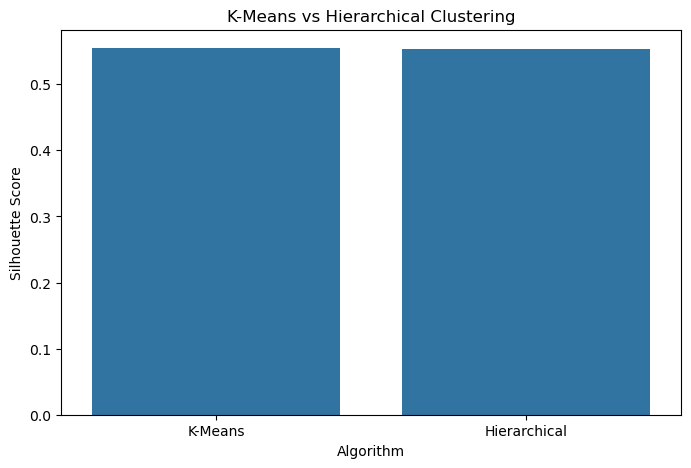

In [61]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=algorithm_comparison,
    x="Algorithm",
    y="Silhouette_Score"
)

plt.title("K-Means vs Hierarchical Clustering")
plt.ylabel("Silhouette Score")

plt.show()

In [63]:
df.to_csv(
    "outputs/results/hierarchical_customer_segments.csv",
    index=False
)

hierarchical_profile.to_csv(
    "outputs/results/hierarchical_cluster_summary.csv"
)

linkage_comparison.to_csv(
    "outputs/results/hierarchical_linkage_comparison.csv",
    index=False
)

print("Hierarchical results saved successfully.")

Hierarchical results saved successfully.


In [65]:
import os

files = [
    "outputs/results/hierarchical_customer_segments.csv",
    "outputs/results/hierarchical_cluster_summary.csv",
    "outputs/results/hierarchical_linkage_comparison.csv"
]

for file in files:
    print(file, "→", os.path.exists(file))

outputs/results/hierarchical_customer_segments.csv → True
outputs/results/hierarchical_cluster_summary.csv → True
outputs/results/hierarchical_linkage_comparison.csv → True


In [67]:
import joblib

joblib.dump(
    scaler,
    "models/hierarchical_scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [69]:
df.to_csv(
    "outputs/results/hierarchical_customer_segments.csv",
    index=False
)

print("Customer segments saved.")

Customer segments saved.


In [71]:
hierarchical_profile.to_csv(
    "outputs/results/hierarchical_cluster_summary.csv"
)

print("Cluster profile saved.")

Cluster profile saved.


In [73]:
linkage_comparison.to_csv(
    "outputs/results/hierarchical_linkage_comparison.csv",
    index=False
)

print("Linkage comparison saved.")

Linkage comparison saved.


In [75]:
import joblib

joblib.dump(
    scaler,
    "models/hierarchical_scaler.pkl"
)

print("Scaler saved.")

Scaler saved.


In [77]:
import os

files = [
    "outputs/results/hierarchical_customer_segments.csv",
    "outputs/results/hierarchical_cluster_summary.csv",
    "outputs/results/hierarchical_linkage_comparison.csv",
    "models/hierarchical_scaler.pkl"
]

for file in files:
    print(f"{file}: {os.path.exists(file)}")

outputs/results/hierarchical_customer_segments.csv: True
outputs/results/hierarchical_cluster_summary.csv: True
outputs/results/hierarchical_linkage_comparison.csv: True
models/hierarchical_scaler.pkl: True
